#### Prompt Chaining
Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and control when working with large language models.
LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.


#### How Prompt Chaining Works with LangGraph
1. Define the Task: Start by breaking down the problem into smaller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like "gather data," "analyze data," and "write summary."

2. Create Nodes: Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text."

3. Establish Edges: Edges define the sequence and dependencies between nodes. For instance, the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the necessary context to proceed.

4. Execute the Graph: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. Iterate if Needed: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"]="true"

In [8]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x00000212580B1070>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000212580B0800>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
llm.invoke("hi, my name is saran")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "hi, my name is saran"\n   - Key information: Greeting ("hi"), name introduction ("my name is saran")\n   - Tone: Casual, friendly\n\n2.  **Identify Key Requirements:**\n   - Acknowledge the greeting\n   - Use the provided name ("Saran" - capitalize properly)\n   - Respond in a friendly, welcoming manner\n   - Keep it concise\n   - Offer assistance\n\n3.  **Formulate Response:**\n   - Greeting back: "Hi Saran!"\n   - Acknowledge name: "Nice to meet you!"\n   - Offer help: "How can I assist you today?"\n   - Keep it warm and open-ended.\n\n4.  **Refine Response:**\n   "Hi Saran! Nice to meet you. How can I help you today?" \n   - Checks: Uses name correctly, friendly, concise, invites next step.\n\n5.  **Final Output Generation:** (matches the refined version)✅\n   "Hi Saran! Nice to meet you. How can I help you today?"\n</think>\n\nHi Saran! Nice to meet you. How can I help you tod

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    topic:str
    story:str
    improved_story:str
    final_story:str

def generate_story(state:State):
    msg=llm.invoke(f"write a story about {state["topic"]}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    else:
        return "pass"

def improved_story(state:State):
    msg=llm.invoke(f"please improve the story further{state["story"]}")
    return {"improved_story":msg.content}

def polished_story(state:State):
    msg=llm.invoke(f"please ploish this story and give the final story{state["improved_story"]}")
    return {"final_story":msg.content}

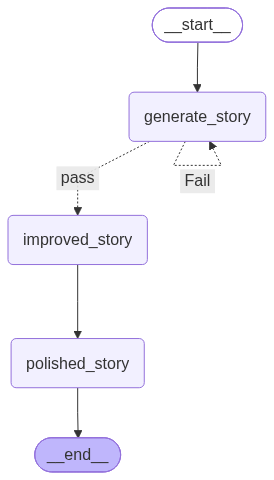

In [11]:
graph = StateGraph(State)
graph.add_node("generate_story", generate_story)
graph.add_node("improved_story", improved_story)
graph.add_node("polished_story", polished_story)

graph.add_edge(START, "generate_story")
graph.add_conditional_edges("generate_story", check_conflict, {"pass":"improved_story", 
                                                               "Fail":"generate_story"})
graph.add_edge("improved_story","polished_story")
graph.add_edge("polished_story", END)

compile_graph = graph.compile()

graph_image = compile_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))


In [12]:
compile_graph.invoke({"topic":"love"})

{'topic': 'love',
 'story': '\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Request:**\n   - **Topic:** Love\n   - **Format:** Story\n   - **Tone:** Open, but typically stories about love benefit from emotional depth, authenticity, and a clear narrative arc.\n   - **Length:** Not specified, so I\'ll aim for a complete, self-contained short story (around 800-1200 words).\n\n2.  **Brainstorming Core Elements:**\n   - **Theme:** Love isn\'t always grand gestures; it\'s often found in quiet, consistent moments. It evolves, faces challenges, and endures through choice.\n   - **Characters:** Two people with distinct personalities, maybe meeting later in life or rekindling something old. Let\'s go with two people who meet in their 40s, both carrying past wounds but ready to try again. Names: Elias and Clara.\n   - **Setting:** A small coastal town, a secondhand bookstore, rainy afternoons, a community garden. Grounded, evocative, slightly nostalgic.\n   - **Plot Arc:** \n     - 

Benefits of Prompt Chaining with LangGraph
- Improved Context Management: By breaking tasks into smaller prompts, the model can focus on one aspect at a time, reducing the risk of losing context in long inputs.

- Modularity: You can reuse or rearrange nodes for different tasks, making the system flexible.

- Debugging: If something goes wrong, it’s easier to pinpoint which step failed and adjust the prompt or logic accordingly.

- Complex Reasoning: Chaining prompts allows the model to "think" step-by-step, mimicking human problem-solving more effectively.